In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42 
import matplotlib.pyplot as plt

dataf=pd.read_csv("/mnt/lab_data2/anusri/print_analysis/newselectedBAChg38.txt", sep="\t", header=None)




In [2]:
dataf.head()

,0,1,2
0,chr1,10317268,10508771
1,chr1,2115312,2276873
2,chr1,69256017,69397675
3,chr1,173236370,173383209
4,chr1,80688374,80857832


In [3]:
import pyBigWig 
tn5_observed = pyBigWig.open("/mnt/lab_data2/anusri/print_analysis/data/naked_unstranded.bw")
printbw = pyBigWig.open("/mnt/lab_data2/anusri/print_analysis/printTn5bias.bw")
observed = pyBigWig.open("/mnt/lab_data2/anusri/chrombpnet/results/chrombpnet/ATAC_PE/GM12878/data/GM12878_unstranded.bw")
from scipy.stats import pearsonr

In [4]:
import os

chr_to_fold={
    "chr1":0,
    "chr3":0,
    "chr6":0,
    "chr2":1,
    "chr8":1,
    "chr9":1,
    "chr16":1,
    "chr4":2,
    "chr11":2,
    "chr12":2,
    "chr15":2,
    "chrY":2, "chr5": 3, "chr10": 3, "chr14": 3, "chr18": 3, "chr20": 3, "chr22": 3, "chr7": 4, 
    "chr13": 4, "chr17": 4,  "chr19": 4, "chr21": 4,  "chrX": 4 
}

coordinates = []
chrombpnet_invivo = []
chrombpnet_naked = []
print_invivo = []
print_naked = []
observed_pear = []

for i,r in dataf.iterrows():
    chrom=r[0]
    startm=r[1]
    endm=r[2]
    foldn=chr_to_fold[chrom]
    idn=str(foldn)
    #print(chrom)
    ofile="/mnt/lab_data2/anusri/print_analysis/make_bg_bigwig/GM12878/ATAC_bias_fold"+idn+"_"+chrom+"_w_bias.bw"
    if not os.path.isfile(ofile):
        print(ofile)
        continue
    bw = pyBigWig.open("/mnt/lab_data2/anusri/print_analysis/make_bg_bigwig/GM12878/ATAC_bias_fold"+idn+"_"+chrom+"_w_bias.bw")
    
    for start in range(startm, endm-1000, 1000):
        end = start + 1000
        coordinates.append(start)
        obs = np.nan_to_num(observed.values(chrom, start, end))
        tn5_obs = np.nan_to_num(tn5_observed.values(chrom, start, end))
        signal_print = np.nan_to_num(printbw.values(chrom, start, end))
        signal_chrom = np.nan_to_num(bw.values(chrom, start, end))

        print_invivo.append(pearsonr(obs, signal_print/sum(signal_print))[0])
        print_naked.append(pearsonr(tn5_obs, signal_print/sum(signal_print))[0])

        chrombpnet_invivo.append(pearsonr(obs, signal_chrom/sum(signal_chrom))[0])
        chrombpnet_naked.append(pearsonr(tn5_obs, signal_chrom/sum(signal_chrom))[0])

        observed_pear.append(pearsonr(obs,tn5_obs)[0])
    bw.close()

/users/anusri/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:4023: PearsonRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(PearsonRConstantInputWarning())


/mnt/lab_data2/anusri/print_analysis/make_bg_bigwig/GM12878/ATAC_bias_fold1_chr2_w_bias.bw
/mnt/lab_data2/anusri/print_analysis/make_bg_bigwig/GM12878/ATAC_bias_fold1_chr2_w_bias.bw
/mnt/lab_data2/anusri/print_analysis/make_bg_bigwig/GM12878/ATAC_bias_fold1_chr2_w_bias.bw
/mnt/lab_data2/anusri/print_analysis/make_bg_bigwig/GM12878/ATAC_bias_fold1_chr2_w_bias.bw


In [5]:
import pandas as pd

df = pd.DataFrame()
df["chrombpnet_invivo"] = chrombpnet_invivo
df["chrombpnet_naked"] = chrombpnet_naked
df["print_invivo"] = print_invivo
df["print_naked"] = print_naked
df["observed_pear"] = observed_pear
df["coordinates"] = coordinates


Text(0, 0.5, 'PRINT')

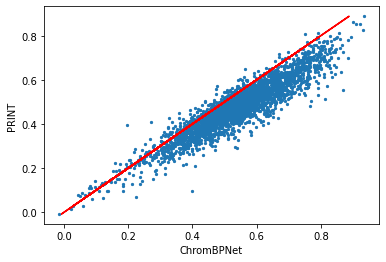

In [6]:
plt.plot(print_invivo, print_invivo, c="r")
plt.scatter(chrombpnet_invivo, print_invivo, s=5)
plt.xlabel("ChromBPNet")
plt.ylabel("PRINT")


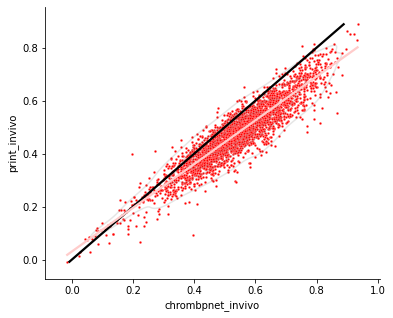

In [8]:
import seaborn as sns
plt.figure(figsize=(6,5))

data=df
sns.kdeplot(
    data=data,
    x="chrombpnet_invivo",
    y="print_invivo",
    levels=5,
    fill=False,
    alpha=0.2,
    color="grey",
    cut=2,

)


ax = sns.scatterplot(x="chrombpnet_invivo", y="print_invivo", data=data, s=6, color="Red", rasterized=True)
sns.regplot(x="print_invivo", y="print_invivo", data=data, scatter=False, ci=None, color="black")
sns.regplot(x="chrombpnet_invivo", y="print_invivo", data=data, scatter=False, ci=None, color="#ffcccb")
ax.spines[["top", "right"]].set_visible(False)
plt.savefig("figures/print_chrombpnet_pearsonr_with_invivo.pdf", dpi=300, transparent=True)
#atc_pear = scipy.stats.pearsonr(data["chrombpnet_invivo"],data["print_invivo"])
#print(atc_pear)
#ax.set_title("Pearsonr = "+str(np.round(atc_pear[0],2)))

In [15]:
df["observed_pear"].mean()

0.5173140653241526

In [16]:
df["observed_pear"].min()

-0.01119249548529871

In [17]:
df["observed_pear"].max()

0.9287953687708221

In [18]:
#observed_pear

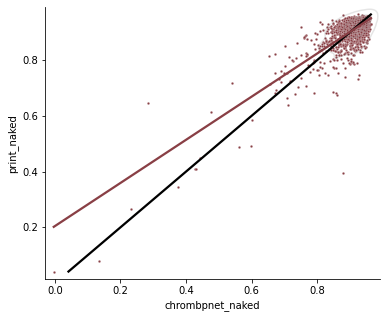

In [14]:
import seaborn as sns
plt.figure(figsize=(6,5))

data=df
sns.kdeplot(
    data=data,
    x="chrombpnet_naked",
    y="print_naked",
    levels=5,
    fill=False,
    alpha=0.2,
    color="grey",
    cut=2,

)


ax = sns.scatterplot(x="chrombpnet_naked", y="print_naked", data=data, s=6, color="#893f45", rasterized=True)
sns.regplot(x="print_naked", y="print_naked", data=data, scatter=False, ci=None, color="black")
sns.regplot(x="chrombpnet_naked", y="print_naked", data=data, scatter=False, ci=None, color="#893f45")
ax.spines[["top", "right"]].set_visible(False)
plt.savefig("figures/print_chrombpnet_pearsonr_with_naked.pdf", dpi=300, transparent=True)
#atc_pear = scipy.stats.pearsonr(data["chrombpnet_invivo"],data["print_invivo"])
#print(atc_pear)
#ax.set_title("Pearsonr = "+str(np.round(atc_pear[0],2)))

In [15]:
# plt.plot(print_naked, print_naked, c="r")
# plt.scatter(chrombpnet_naked, print_naked, s=5)
# # plt.xlim(0.8,1)
# # plt.ylim(0.8,1)
# plt.xlabel("ChromBPNet")
# plt.ylabel("PRINT")

(array([  2.,   2.,   2.,   5.,   2.,   7.,   5.,   4.,   5.,   7.,   5.,
          9.,  16.,  11.,  19.,  28.,  36.,  45.,  42.,  67.,  69.,  94.,
        120., 148., 140., 161., 169., 180., 186., 166., 165., 193., 162.,
         97., 102.,  77.,  75.,  56.,  58.,  46.,  41.,  22.,  25.,  15.,
         11.,   3.,   3.,   2.,   1.,   3.]),
 array([-0.0111925 ,  0.00760726,  0.02640702,  0.04520678,  0.06400653,
         0.08280629,  0.10160605,  0.12040581,  0.13920556,  0.15800532,
         0.17680508,  0.19560483,  0.21440459,  0.23320435,  0.25200411,
         0.27080386,  0.28960362,  0.30840338,  0.32720314,  0.34600289,
         0.36480265,  0.38360241,  0.40240216,  0.42120192,  0.44000168,
         0.45880144,  0.47760119,  0.49640095,  0.51520071,  0.53400047,
         0.55280022,  0.57159998,  0.59039974,  0.60919949,  0.62799925,
         0.64679901,  0.66559877,  0.68439852,  0.70319828,  0.72199804,
         0.7407978 ,  0.75959755,  0.77839731,  0.79719707,  0.81599683,
 

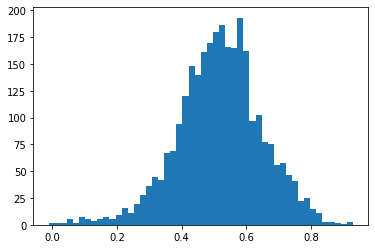

In [16]:
plt.hist(observed_pear, bins=50)

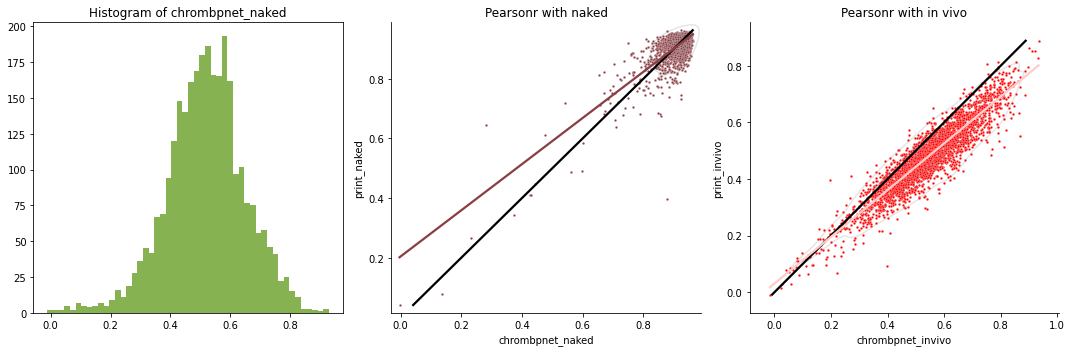

In [22]:
# Assuming df is your DataFrame
data = df

observed_pear = df["observed_pear"]

# Create the figure and define subplots
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# First plot: Histogram
ax[0].hist(observed_pear, bins=50, color="#86b251")
ax[0].set_title("Histogram of chrombpnet_naked")

# Second plot: KDE and scatter for naked
sns.kdeplot(
    data=data,
    x="chrombpnet_naked",
    y="print_naked",
    levels=5,
    fill=False,
    alpha=0.2,
    color="grey",
    cut=2,
    ax=ax[1]
)
sns.scatterplot(x="chrombpnet_naked", y="print_naked", data=data, s=6, color="#893f45", rasterized=True, ax=ax[1])
sns.regplot(x="print_naked", y="print_naked", data=data, scatter=False, ci=None, color="black", ax=ax[1])
sns.regplot(x="chrombpnet_naked", y="print_naked", data=data, scatter=False, ci=None, color="#893f45", ax=ax[1])
ax[1].spines[["top", "right"]].set_visible(False)
ax[1].set_title("Pearsonr with naked")

# Third plot: KDE and scatter for in vivo
sns.kdeplot(
    data=data,
    x="chrombpnet_invivo",
    y="print_invivo",
    levels=5,
    fill=False,
    alpha=0.2,
    color="grey",
    cut=2,
    ax=ax[2]
)
sns.scatterplot(x="chrombpnet_invivo", y="print_invivo", data=data, s=6, color="Red", rasterized=True, ax=ax[2])
sns.regplot(x="print_invivo", y="print_invivo", data=data, scatter=False, ci=None, color="black", ax=ax[2])
sns.regplot(x="chrombpnet_invivo", y="print_invivo", data=data, scatter=False, ci=None, color="#ffcccb", ax=ax[2])
ax[2].spines[["top", "right"]].set_visible(False)
ax[2].set_title("Pearsonr with in vivo")

plt.tight_layout()
plt.savefig("figures/chrombpnet_vs_print_combined_plot_pearsonr_dist.pdf", dpi=300, transparent=True)
#plt.show()

In [19]:
import os
from scipy.stats import spearmanr

chr_to_fold={
    "chr1":0,
    "chr3":0,
    "chr6":0,
    "chr2":1,
    "chr8":1,
    "chr9":1,
    "chr16":1,
    "chr4":2,
    "chr11":2,
    "chr12":2,
    "chr15":2,
    "chrY":2, "chr5": 3, "chr10": 3, "chr14": 3, "chr18": 3, "chr20": 3, "chr22": 3, "chr7": 4, 
    "chr13": 4, "chr17": 4,  "chr19": 4, "chr21": 4,  "chrX": 4 
}

coordinates = []
chrombpnet_invivo = []
chrombpnet_naked = []
print_invivo = []
print_naked = []
observed_pear = []
for i,r in dataf.iterrows():
    chrom=r[0]
    startm=r[1]
    endm=r[2]


    foldn=chr_to_fold[chrom]
    idn=str(foldn)
    #print(chrom)
    ofile="/mnt/lab_data2/anusri/print_analysis/make_bg_bigwig/GM12878/ATAC_bias_fold"+idn+"_"+chrom+"_w_bias.bw"
    if not os.path.isfile(ofile):
        print(ofile)
        continue
    bw = pyBigWig.open("/mnt/lab_data2/anusri/print_analysis/make_bg_bigwig/GM12878/ATAC_bias_fold"+idn+"_"+chrom+"_w_bias.bw")
    
    for start in range(startm, endm-1000, 1000):
        end = start + 1000
        coordinates.append(start)
        obs = np.nan_to_num(observed.values(chrom, start, end))
        tn5_obs = np.nan_to_num(tn5_observed.values(chrom, start, end))
        signal_print = np.nan_to_num(printbw.values(chrom, start, end))
        signal_chrom = np.nan_to_num(bw.values(chrom, start, end))

        print_invivo.append(spearmanr(obs, signal_print/sum(signal_print))[0])
        print_naked.append(spearmanr(tn5_obs, signal_print/sum(signal_print))[0])

        chrombpnet_invivo.append(spearmanr(obs, signal_chrom/sum(signal_chrom))[0])
        chrombpnet_naked.append(spearmanr(tn5_obs, signal_chrom/sum(signal_chrom))[0])

        observed_pear.append(spearmanr(obs,tn5_obs)[0])
    bw.close()

/users/anusri/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:4484: SpearmanRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(SpearmanRConstantInputWarning())


/mnt/lab_data2/anusri/print_analysis/make_bg_bigwig/GM12878/ATAC_bias_fold1_chr2_w_bias.bw
/mnt/lab_data2/anusri/print_analysis/make_bg_bigwig/GM12878/ATAC_bias_fold1_chr2_w_bias.bw
/mnt/lab_data2/anusri/print_analysis/make_bg_bigwig/GM12878/ATAC_bias_fold1_chr2_w_bias.bw
/mnt/lab_data2/anusri/print_analysis/make_bg_bigwig/GM12878/ATAC_bias_fold1_chr2_w_bias.bw


In [21]:
import pandas as pd

df = pd.DataFrame()
df["chrombpnet_invivo"] = chrombpnet_invivo
df["chrombpnet_naked"] = chrombpnet_naked
df["print_invivo"] = print_invivo
df["print_naked"] = print_naked
df["observed_pear"] = observed_pear
df["coordinates"] = coordinates

In [22]:
df["observed_pear"].mean()

0.39063715783433023

In [23]:
df["observed_pear"].min()

-0.013216279381043201

In [24]:
df["observed_pear"].max()

0.8985406643148894

In [25]:
# plt.plot(print_invivo, print_invivo, c="r")
# plt.scatter(chrombpnet_invivo, print_invivo, s=5)
# plt.xlabel("ChromBPNet")
# plt.ylabel("PRINT")

In [26]:
# plt.plot(print_naked, print_naked, c="r")
# plt.scatter(chrombpnet_naked, print_naked, s=5)
# # plt.xlim(0.8,1)
# # plt.ylim(0.8,1)
# plt.xlabel("ChromBPNet")
# plt.ylabel("PRINT")

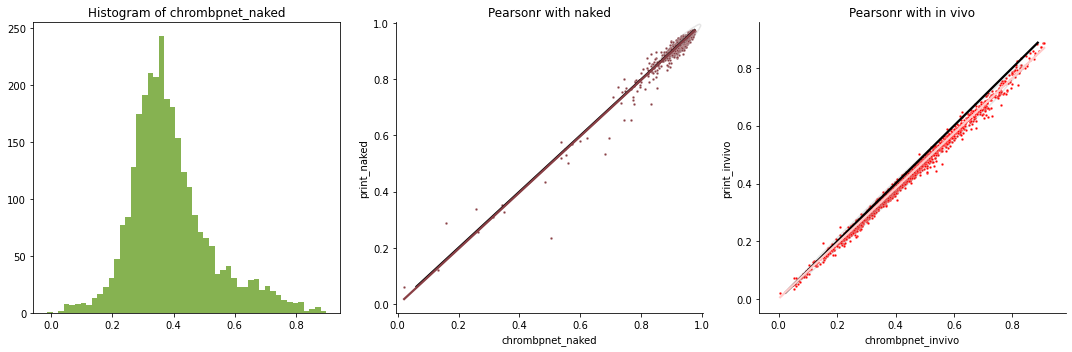

In [27]:
# Assuming df is your DataFrame
data = df

observed_pear = df["observed_pear"]

# Create the figure and define subplots
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# First plot: Histogram
ax[0].hist(observed_pear, bins=50, color="#86b251")
ax[0].set_title("Histogram of chrombpnet_naked")

# Second plot: KDE and scatter for naked
sns.kdeplot(
    data=data,
    x="chrombpnet_naked",
    y="print_naked",
    levels=5,
    fill=False,
    alpha=0.2,
    color="grey",
    cut=2,
    ax=ax[1]
)
sns.scatterplot(x="chrombpnet_naked", y="print_naked", data=data, s=6, color="#893f45", rasterized=True, ax=ax[1])
sns.regplot(x="print_naked", y="print_naked", data=data, scatter=False, ci=None, color="black", ax=ax[1])
sns.regplot(x="chrombpnet_naked", y="print_naked", data=data, scatter=False, ci=None, color="#893f45", ax=ax[1])
ax[1].spines[["top", "right"]].set_visible(False)
ax[1].set_title("Pearsonr with naked")

# Third plot: KDE and scatter for in vivo
sns.kdeplot(
    data=data,
    x="chrombpnet_invivo",
    y="print_invivo",
    levels=5,
    fill=False,
    alpha=0.2,
    color="grey",
    cut=2,
    ax=ax[2]
)
sns.scatterplot(x="chrombpnet_invivo", y="print_invivo", data=data, s=6, color="Red", rasterized=True, ax=ax[2])
sns.regplot(x="print_invivo", y="print_invivo", data=data, scatter=False, ci=None, color="black", ax=ax[2])
sns.regplot(x="chrombpnet_invivo", y="print_invivo", data=data, scatter=False, ci=None, color="#ffcccb", ax=ax[2])
ax[2].spines[["top", "right"]].set_visible(False)
ax[2].set_title("Pearsonr with in vivo")

plt.tight_layout()
plt.savefig("figures/chrombpnet_vs_print_combined_plot_spearmanr_dist.pdf", dpi=300, transparent=True)
#plt.show()

In [28]:
#plt.hist(observed_pear, bins=50)

In [26]:
from scipy.spatial import distance

In [27]:
import os

chr_to_fold={
    "chr1":0,
    "chr3":0,
    "chr6":0,
    "chr2":1,
    "chr8":1,
    "chr9":1,
    "chr16":1,
    "chr4":2,
    "chr11":2,
    "chr12":2,
    "chr15":2,
    "chrY":2, "chr5": 3, "chr10": 3, "chr14": 3, "chr18": 3, "chr20": 3, "chr22": 3, "chr7": 4, 
    "chr13": 4, "chr17": 4,  "chr19": 4, "chr21": 4,  "chrX": 4 
}

coordinates = []
chrombpnet_invivo = []
chrombpnet_naked = []
print_invivo = []
print_naked = []
observed_pear = []
for i,r in dataf.iterrows():
    chrom=r[0]
    startm=r[1]
    endm=r[2]


    foldn=chr_to_fold[chrom]
    idn=str(foldn)
    #print(chrom)
    ofile="/mnt/lab_data2/anusri/print_analysis/make_bg_bigwig/GM12878/ATAC_bias_fold"+idn+"_"+chrom+"_w_bias.bw"
    if not os.path.isfile(ofile):
        print(ofile)
        continue
    bw = pyBigWig.open("/mnt/lab_data2/anusri/print_analysis/make_bg_bigwig/GM12878/ATAC_bias_fold"+idn+"_"+chrom+"_w_bias.bw")
    
    for start in range(startm, endm-1000, 1000):
        end = start + 1000
        coordinates.append(start)
        obs = np.nan_to_num(observed.values(chrom, start, end))
        tn5_obs = np.nan_to_num(tn5_observed.values(chrom, start, end))
        signal_print = np.nan_to_num(printbw.values(chrom, start, end))
        signal_chrom = np.nan_to_num(bw.values(chrom, start, end))

        print_invivo.append(distance.jensenshannon(obs+1e-12, signal_print/sum(signal_print), base=2))
        print_naked.append(distance.jensenshannon(tn5_obs+1e-12, signal_print/sum(signal_print), base=2))

        chrombpnet_invivo.append(distance.jensenshannon(obs+1e-12, signal_chrom/sum(signal_chrom), base=2))
        chrombpnet_naked.append(distance.jensenshannon(tn5_obs+1e-12, signal_chrom/sum(signal_chrom), base=2))

        observed_pear.append(distance.jensenshannon(obs+1e-12,tn5_obs+1e-12, base=2))
    bw.close()

/mnt/lab_data2/anusri/print_analysis/make_bg_bigwig/GM12878/ATAC_bias_fold1_chr2_w_bias.bw
/mnt/lab_data2/anusri/print_analysis/make_bg_bigwig/GM12878/ATAC_bias_fold1_chr2_w_bias.bw
/mnt/lab_data2/anusri/print_analysis/make_bg_bigwig/GM12878/ATAC_bias_fold1_chr2_w_bias.bw
/mnt/lab_data2/anusri/print_analysis/make_bg_bigwig/GM12878/ATAC_bias_fold1_chr2_w_bias.bw


In [28]:
import pandas as pd

df = pd.DataFrame()
df["chrombpnet_invivo"] = chrombpnet_invivo
df["chrombpnet_naked"] = chrombpnet_naked
df["print_invivo"] = print_invivo
df["print_naked"] = print_naked
df["observed_pear"] = observed_pear
df["coordinates"] = coordinates

In [29]:
df["observed_pear"].mean()

0.6922787239948164

In [30]:
df["observed_pear"].min()

0.22264655775830583

In [31]:
df["observed_pear"].max()

0.9999999999711094

In [49]:
#plt.hist(observed_pear, bins=50)

In [50]:
# plt.plot(print_naked, print_naked, c="r")
# plt.scatter(chrombpnet_naked, print_naked, s=5)
# # plt.xlim(0.8,1)
# # plt.ylim(0.8,1)
# plt.xlabel("ChromBPNet")
# plt.ylabel("PRINT")

In [51]:
# plt.plot(print_invivo, print_invivo, c="r")
# plt.scatter(chrombpnet_invivo, print_invivo, s=5)
# plt.xlabel("ChromBPNet")
# plt.ylabel("PRINT")

/users/anusri/anaconda3/lib/python3.7/site-packages/seaborn/distributions.py:1077: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)
/users/anusri/anaconda3/lib/python3.7/site-packages/seaborn/distributions.py:1077: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)


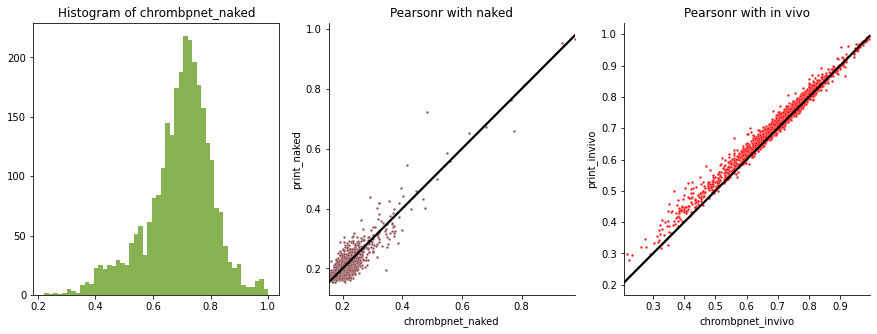

In [54]:
#coordinates
# Assuming df is your DataFrame
# Assuming df is your DataFrame

# Remove rows with any NA values
data = df.dropna()

# Assuming df is your DataFrame
#data = df

observed_pear = df["observed_pear"]

# Create the figure and define subplots
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# First plot: Histogram
ax[0].hist(observed_pear, bins=50, color="#86b251")
ax[0].set_title("Histogram of chrombpnet_naked")

# Second plot: KDE and scatter for naked
sns.kdeplot(
    data=data,
    x="chrombpnet_naked",
    y="print_naked",
    levels=5,
    fill=False,
    alpha=0.2,
    color="grey",
    cut=2,
    ax=ax[1]
)
sns.scatterplot(x="chrombpnet_naked", y="print_naked", data=data, s=6, color="#893f45", rasterized=True, ax=ax[1])
sns.regplot(x="chrombpnet_naked", y="chrombpnet_naked", data=data, scatter=False, ci=None, color="black", ax=ax[1])
sns.regplot(x="chrombpnet_naked", y="print_naked", data=data, scatter=False, ci=None, color="#893f45", ax=ax[1])
ax[1].spines[["top", "right"]].set_visible(False)
ax[1].set_title("Pearsonr with naked")

# Third plot: KDE and scatter for in vivo
sns.kdeplot(
    data=data,
    x="chrombpnet_invivo",
    y="print_invivo",
    levels=5,
    fill=False,
    alpha=0.2,
    color="grey",
    cut=2,
    ax=ax[2]
)
sns.scatterplot(x="chrombpnet_invivo", y="print_invivo", data=data, s=6, color="Red", rasterized=True, ax=ax[2])
sns.regplot(x="chrombpnet_invivo", y="chrombpnet_invivo", data=data, scatter=False, ci=None, color="black", ax=ax[2])
sns.regplot(x="chrombpnet_invivo", y="print_invivo", data=data, scatter=False, ci=None, color="#ffcccb", ax=ax[2])
ax[2].spines[["top", "right"]].set_visible(False)
ax[2].set_title("Pearsonr with in vivo")

plt.savefig("figures/chrombpnet_vs_print_combined_plot_jsd_dist.pdf", dpi=300, transparent=True)
#plt.show()